In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import random
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from tabpfn_sbi.tasks.allen_task import AllenTask
from tabpfn_sbi.utils import plot_metric_by_num_simulations, use_style
from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS, plot_calibration_curves

work_dir = os.environ.get("WORK")
print(work_dir)


def set_seed(seed: int):
    """This methods just sets the seed."""
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

/mnt/lustre/work/macke/mwe824


(task=='allen') & (metric=='standardized_distance')
(task=='allen') & (metric=='standardized_distance')


/mnt/lustre/work/macke/mwe824/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/mnt/lustre/work/macke/mwe824/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/mnt/lustre/work/macke/mwe824/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


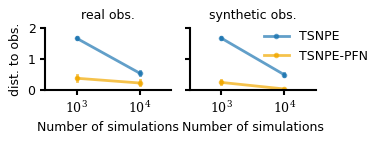

In [3]:
with use_style("pyloric"):
    fig, axes = plt.subplots(1, 2, figsize=(4, 1.55), sharey=True)
    name_real = "../../main_results/allen"
    plot_metric_by_num_simulations(
        name_real,
        task="allen",
        metric="standardized_distance",
        hue="method",
        color_map=DEFAULT_COLORS,
        ax=axes[0],
    )
    axes[0].set_ylim(0, 2)
    axes[0].legend().set_visible(False)
    axes[0].set_title("real obs.")

    name_synth = "../../main_results/allen_synth"
    plot_metric_by_num_simulations(
        name_synth,
        task="allen",
        metric="standardized_distance",
        hue="method",
        color_map=DEFAULT_COLORS,
        ax=axes[1],
    )
    legend = axes[1].legend(loc="center")
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].set_title("synthetic obs.")

    label_map = {
        "tsnpe": "TSNPE",
        "ts_tabpfn": "TSNPE-PFN",
    }

    new_labels = [label_map.get(label, label) for label in labels]
    axes[1].legend(handles, new_labels, loc="center", bbox_to_anchor=(1.0, 0.7))

    plt.tight_layout()
    fig.savefig("distances.svg", bbox_inches="tight")

In [4]:
# local stuff that requires models
run_result_dir = os.path.join(work_dir, "tabpfn_sbi/results/allen")
csv_path = os.path.join(run_result_dir, "summary.csv")

df = pd.read_csv(csv_path)

print(df)

task_name = "allen"
num_simulations = 10000
seed = 3

allen_task_real = AllenTask(cache_dir=work_dir, obs_type="real")
prior = allen_task_real.get_prior_dist()
simulator = allen_task_real.get_simulator()

        method estimator embedding_net   task  num_simulations  seed  \
0    ts_tabpfn      none          none  allen             1000     0   
1    ts_tabpfn      none          none  allen             1000     0   
2    ts_tabpfn      none          none  allen             1000     0   
3    ts_tabpfn      none          none  allen             1000     0   
4    ts_tabpfn      none          none  allen             1000     0   
..         ...       ...           ...    ...              ...   ...   
195      tsnpe       nsf          none  allen            10000     4   
196      tsnpe       nsf          none  allen            10000     4   
197      tsnpe       nsf          none  allen            10000     4   
198      tsnpe       nsf          none  allen            10000     4   
199  ts_tabpfn      none          none  allen            10000     3   

                                 model_id observation_ids  \
0                                       0            [10]   
1            

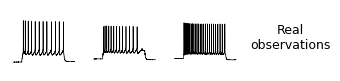

7206cb53-13c7-4f4e-8241-f74384951540
<class 'tabpfn_sbi.methods.tabpfn_sbi.FilteredTabPFNSBI'>
Sampling took 49.39s
6e2b55e9-e9a1-4229-b822-120d05315dd8
<class 'tabpfn_sbi.methods.tabpfn_sbi.FilteredTabPFNSBI'>
Sampling took 50.03s
1ab40399-65f7-4216-8bde-8958ca715a4b
<class 'tabpfn_sbi.methods.tabpfn_sbi.FilteredTabPFNSBI'>
Sampling took 58.42s


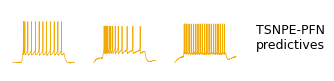

c9369a67-e46c-45ff-b3b3-51dfb844a2f0
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.03s
5b123162-b98a-4c4b-9926-fcb642d9f9f7
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>


/home/macke/mwe824/.conda/envs/tabpfn/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2253.)
  outputs, _ = torch.triangular_solve(


Sampling took 0.02s
36492ef5-bc7a-4678-b9b5-fdd55e8b5995
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.02s


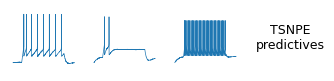

In [5]:
observation_ids = [5, 7, 8]
seed = 4
num_simulations = 10000
task_name = "allen"

fig_size = (4, 0.8)

with use_style("pyloric"):
    fig, axes = plt.subplots(1, len(observation_ids) + 1, figsize=fig_size)

    for idx, obs_id in enumerate(observation_ids):
        raw_obs = allen_task_real.get_real_observation(obs_id)
        axes[idx].plot(raw_obs["data"], color="black", linewidth=0.5)
        axes[idx].set_ylim((-110, 60))
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)
        axes[idx].spines["bottom"].set_visible(False)
        axes[idx].spines["left"].set_visible(False)

    axes[-1].axis("off")
    fig.suptitle("Real\nobservations", ha="center", x=0.825, y=0.7)
    fig.savefig("real_observations.svg", bbox_inches="tight")


for method_name in ["ts_tabpfn", "tsnpe"]:
    with use_style("pyloric"):
        fig, axes = plt.subplots(1, len(observation_ids) + 1, figsize=fig_size)

        for idx, obs_id in enumerate(observation_ids):
            query_conditions = [
                f"method == '{method_name}'",
                f"task == '{task_name}'",
                f"num_simulations == {num_simulations}",
                f"seed == {seed}",
                f"observation_ids == '[{obs_id}]'",
            ]
            query_string = " and ".join(query_conditions)

            filtered_df = df.query(query_string)
            assert len(filtered_df) == 1
            row = filtered_df.iloc[0]

            obs = allen_task_real.get_observation(
                int(row["observation_ids"].strip("[]")), device="cpu"
            )
            model_id = row["model_id"]
            print(model_id)
            with open(
                os.path.join(run_result_dir, f"models/model_{model_id}.pkl"), "rb"
            ) as f:
                posterior = pickle.load(f)

            print(type(posterior))

            start = perf_counter()
            set_seed(33)
            # posterior_samples = posterior.sample((2,), x=obs)
            posterior_samples = posterior.sample((1,), x=obs)
            print(f"Sampling took {perf_counter() - start:.2f}s")

            seeds = np.arange(posterior_samples.shape[0])
            raw_spike_trains = [
                allen_task_real.sim.gen_single(theta, seed=seed)
                for theta, seed in zip(posterior_samples, seeds)
            ]

            spike_train = raw_spike_trains[0]
            axes[idx].plot(
                spike_train["data"],
                color=DEFAULT_COLORS[method_name],
                linewidth=0.5,
            )
            axes[idx].set_ylim((-110, 60))
            axes[idx].set_xticks([])
            axes[idx].set_yticks([])
            axes[idx].spines["top"].set_visible(False)
            axes[idx].spines["right"].set_visible(False)
            axes[idx].spines["bottom"].set_visible(False)
            axes[idx].spines["left"].set_visible(False)

        axes[-1].axis("off")
        if method_name == "ts_tabpfn":
            fig.suptitle("TSNPE-PFN\npredictives", ha="center", x=0.825, y=0.7)
        if method_name == "tsnpe":
            fig.suptitle("TSNPE\npredictives", ha="center", x=0.825, y=0.7)
        fig.savefig(f"{method_name}_predicitives.svg", bbox_inches="tight")

(task=='allen') & (num_simulations==1000) & (metric=='sbc')
(task=='allen') & (num_simulations==10000) & (metric=='sbc')
(task=='allen') & (num_simulations==100000) & (metric=='sbc')
[<matplotlib.lines.Line2D object at 0x7fcd4673f310>, <matplotlib.lines.Line2D object at 0x7fcd467e27d0>, <matplotlib.lines.Line2D object at 0x7fcd467e0850>, <matplotlib.lines.Line2D object at 0x7fcd467e01d0>, <matplotlib.lines.Line2D object at 0x7fcd467e17d0>, <matplotlib.lines.Line2D object at 0x7fcd4f3be990>, <matplotlib.lines.Line2D object at 0x7fcd467b9b10>, <matplotlib.lines.Line2D object at 0x7fcd467ba9d0>, <matplotlib.lines.Line2D object at 0x7fcd467ba310>, <matplotlib.lines.Line2D object at 0x7fcd4f4463d0>]
['filtered_tabpfn', 'filtered_tabpfn', 'filtered_tabpfn', 'filtered_tabpfn', 'filtered_tabpfn', 'npe', 'npe', 'npe', 'npe', 'npe']


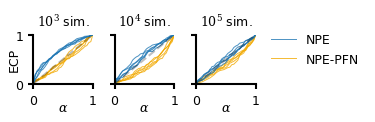

In [6]:
with use_style("pyloric"):
    fig, axes = plt.subplots(1, 3, figsize=(4, 1.3), sharey=True)

    fig.subplots_adjust(wspace=0.5)

    num_sims = [1000, 10000, 100000]
    for idx, num_sim in enumerate(num_sims):
        plot_calibration_curves(
            "../../main_results/allen_synth",
            task="allen",
            metric="sbc",
            num_simulations=num_sim,
            alpha=0.8,
            hue="method",
            plot_mean=False,
            color_map=DEFAULT_COLORS,
            ax=axes[idx],
        )

    axes[0].legend().set_visible(False)
    axes[0].set_title("$10^3$ sim.")
    axes[0].set_ylabel(axes[0].get_ylabel(), labelpad=-4)
    axes[0].set_xlabel(axes[0].get_xlabel(), labelpad=-4)
    axes[1].legend().set_visible(False)
    axes[1].set_title(r"$10^4$ sim.")
    axes[1].set_ylabel("")
    axes[1].set_xlabel(axes[1].get_xlabel(), labelpad=-4)
    # axes[2].legend().set_visible(False)
    axes[2].set_title(r"$10^5$ sim.")
    axes[2].set_ylabel("")
    axes[2].set_xlabel(axes[2].get_xlabel(), labelpad=-4)
    handles, labels = axes[2].get_legend_handles_labels()
    # get first and last element of handles and labels in a new list
    print(handles)
    print(labels)
    label_map = {
        "npe": "NPE",
        "filtered_tabpfn": "NPE-PFN",
    }
    handles = [handles[-1], handles[0]]
    labels = [label_map[labels[-1]], label_map[labels[0]]]
    axes[2].legend(handles, labels, loc="center", bbox_to_anchor=(2, 0.7))

    axes[0].set_yticklabels([0, 1])
    for i in range(3):
        axes[i].set_xticklabels([0, 1])

    fig.tight_layout()
    fig.savefig("sbc_for_amortized.svg", bbox_inches="tight")

In [26]:
run_result_dir = os.path.join(work_dir, "tabpfn_sbi/results/allen_synth")
csv_path = os.path.join(run_result_dir, "summary.csv")

df = pd.read_csv(csv_path)

print(df)

allen_task_synth = AllenTask(cache_dir=work_dir, obs_type="synthetic")
prior = allen_task_synth.get_prior_dist()
simulator = allen_task_synth.get_simulator()

observation_id = 5
seed = 4
num_simulations = 10000
task_name = "allen"

true_params = allen_task_synth.get_gt_theta_synthetic(observation_id)

posterior_samples_dict = {}
for method_name in ["ts_tabpfn", "tsnpe"]:
    query_conditions = [
        f"method == '{method_name}'",
        f"task == 'allen'",
        f"num_simulations == {num_simulations}",
        f"seed == {seed}",
        f"observation_ids == '[{observation_id}]'",
    ]
    query_string = " and ".join(query_conditions)

    filtered_df = df.query(query_string)
    assert len(filtered_df) == 1
    row = filtered_df.iloc[0]

    obs = allen_task_synth.get_observation(
        int(row["observation_ids"].strip("[]")), device="cpu"
    )
    model_id = row["model_id"]
    print(model_id)
    with open(os.path.join(run_result_dir, f"models/model_{model_id}.pkl"), "rb") as f:
        posterior = pickle.load(f)

    print(type(posterior))

    start = perf_counter()
    posterior_samples = posterior.sample((10000,), x=obs)
    print(f"Sampling took {perf_counter() - start:.2f}s")
    posterior_samples_dict[method_name] = posterior_samples

        method estimator embedding_net   task  num_simulations  seed  \
0    ts_tabpfn      none          none  allen             1000     0   
1    ts_tabpfn      none          none  allen             1000     1   
2    ts_tabpfn      none          none  allen             1000     0   
3    ts_tabpfn      none          none  allen             1000     0   
4    ts_tabpfn      none          none  allen             1000     0   
..         ...       ...           ...    ...              ...   ...   
225        npe       nsf          none  allen           100000     0   
226        npe       nsf          none  allen           100000     1   
227        npe       nsf          none  allen           100000     3   
228        npe       nsf          none  allen           100000     2   
229        npe       nsf          none  allen           100000     4   

                                 model_id observation_ids  \
0                                       0             [2]   
1            

tensor(1.5126) tensor(79.9936)
tensor(0.0403) tensor(13.9130)
tensor(0.0001) tensor(0.0663)
tensor(0.0004) tensor(0.5980)
tensor(79.5004) tensor(2999.9749)
tensor(40.4138) tensor(89.4293)
tensor(0.0002) tensor(0.1500)
tensor(36.6702) tensor(97.6450)


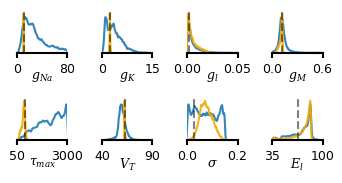

In [27]:
# prior_lower = np.array([0.5, 1e-4, 1e-4, 1e-4, 50.0, 40.0, 1e-4, 35.0])
# prior_upper = np.array([80.0, 15.0, 0.6, 0.6, 3000.0, 90.0, 0.15, 100.0])

# hand picked
x_ticks = [
    [0, 80],
    [0, 15],
    [0.0, 0.05],
    [0.0, 0.6],
    [50, 3000],
    [40, 90],
    [0.0, 0.2],
    [35, 100],
]
labels = [
    # r"$\bar{g}_{Na}$",
    r"$g_{Na}$",
    # r"$\bar{g}_K$",
    r"$g_K$",
    r"$g_l$",
    # r"$\bar{g}_M$",
    r"$g_M$",
    r"$\tau_{max}$",
    r"$V_T$",
    r"$\sigma$",
    r"$E_l$",
]

with use_style("pyloric"):
    fig, axes = plt.subplots(2, 4, figsize=(3.5, 1.9), sharey=True)
    for i in range(8):
        ii, jj = divmod(i, 4)
        sns.kdeplot(
            posterior_samples_dict["tsnpe"][:, i],
            ax=axes[ii, jj],
            bw_adjust=0.3,
        )
        sns.kdeplot(
            posterior_samples_dict["ts_tabpfn"][:, i],
            ax=axes[ii, jj],
            bw_adjust=0.3,
        )

        lines = axes[ii, jj].get_lines()
        tsnpe_x, tsnpe_y = lines[0].get_data()
        ts_tabpfn_x, ts_tabpfn_y = lines[1].get_data()

        for line in lines:
            line.remove()

        axes[ii, jj].plot(
            tsnpe_x, tsnpe_y / tsnpe_y.max(), color=DEFAULT_COLORS["tsnpe"], alpha=0.9
        )
        axes[ii, jj].plot(
            ts_tabpfn_x,
            ts_tabpfn_y / ts_tabpfn_y.max() * 1.1,  # hack for a bit more separation
            color=DEFAULT_COLORS["ts_tabpfn"],
            alpha=0.9,
        )
        axes[ii, jj].set_ylim(0, 1.2)

        # for handpicking
        print(
            posterior_samples_dict["tsnpe"][:, i].min(),
            posterior_samples_dict["tsnpe"][:, i].max(),
        )
        axes[ii, jj].set_xlim(x_ticks[i][0], x_ticks[i][1])
        axes[ii, jj].set_xticks(x_ticks[i])
        axes[ii, jj].axvline(true_params[i], color="black", alpha=0.5, linestyle="--")
        axes[ii, jj].get_yaxis().set_visible(False)
        axes[ii, jj].spines["left"].set_visible(False)

        axes[ii, jj].set_xlabel(labels[i], labelpad=-4)

    fig.tight_layout()
    fig.savefig("posterior_marginals.svg", bbox_inches="tight")